In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# 1. Load the master training dataset you uploaded
df = pd.read_csv('master_training_data_with_ndvi.csv')

# 2. Display the first few rows to verify the data
print(f"Total records in dataset: {len(df)}")
df.head()

Total records in dataset: 6727


,District,Crop,Year,Season,Total_Rainfall_mm,Average_Temp_C,Mean_NDVI,Yield_KG_HA
0,Bugesera,Banana for beer,2015,Season A,553.0,21.241436,0.5452,9389.07
1,Bugesera,Banana for beer,2015,Season B,335.0,21.378261,0.5320,7924.70
2,Bugesera,Banana for beer,2016,Season A,465.6,21.585440,0.5365,9004.56
3,Bugesera,Banana for beer,2016,Season B,281.9,21.780163,0.5149,7329.19
4,Bugesera,Banana for beer,2017,Season A,356.3,21.789779,0.5030,7925.06


In [2]:
# 1. Group the data and calculate the average yield
baseline_df = df.groupby(['District', 'Crop'])['Yield_KG_HA'].mean().reset_index()

# 2. Rename the column for clarity
baseline_df = baseline_df.rename(columns={'Yield_KG_HA': 'Baseline_Yield_KG_HA'})

# 3. Sort the values to make it easy to read
baseline_df = baseline_df.sort_values(by=['District', 'Crop'])

print("Top 10 Baseline Yields (KG/HA):")
baseline_df.head(10)

Top 10 Baseline Yields (KG/HA):


,District,Crop,Baseline_Yield_KG_HA
0,Bugesera,Banana for beer,8345.132857
1,Bugesera,Bananas,10135.384286
2,Bugesera,Beans,668.370000
3,Bugesera,Bush bean,678.773571
4,Bugesera,Cassava,16980.520000
5,Bugesera,Climbing bean,640.557857
6,Bugesera,Cooking Banana,13941.298571
7,Bugesera,Dessert banana,9987.255000
8,Bugesera,Ground nuts,424.891429
9,Bugesera,Irish potatoes,2376.120000


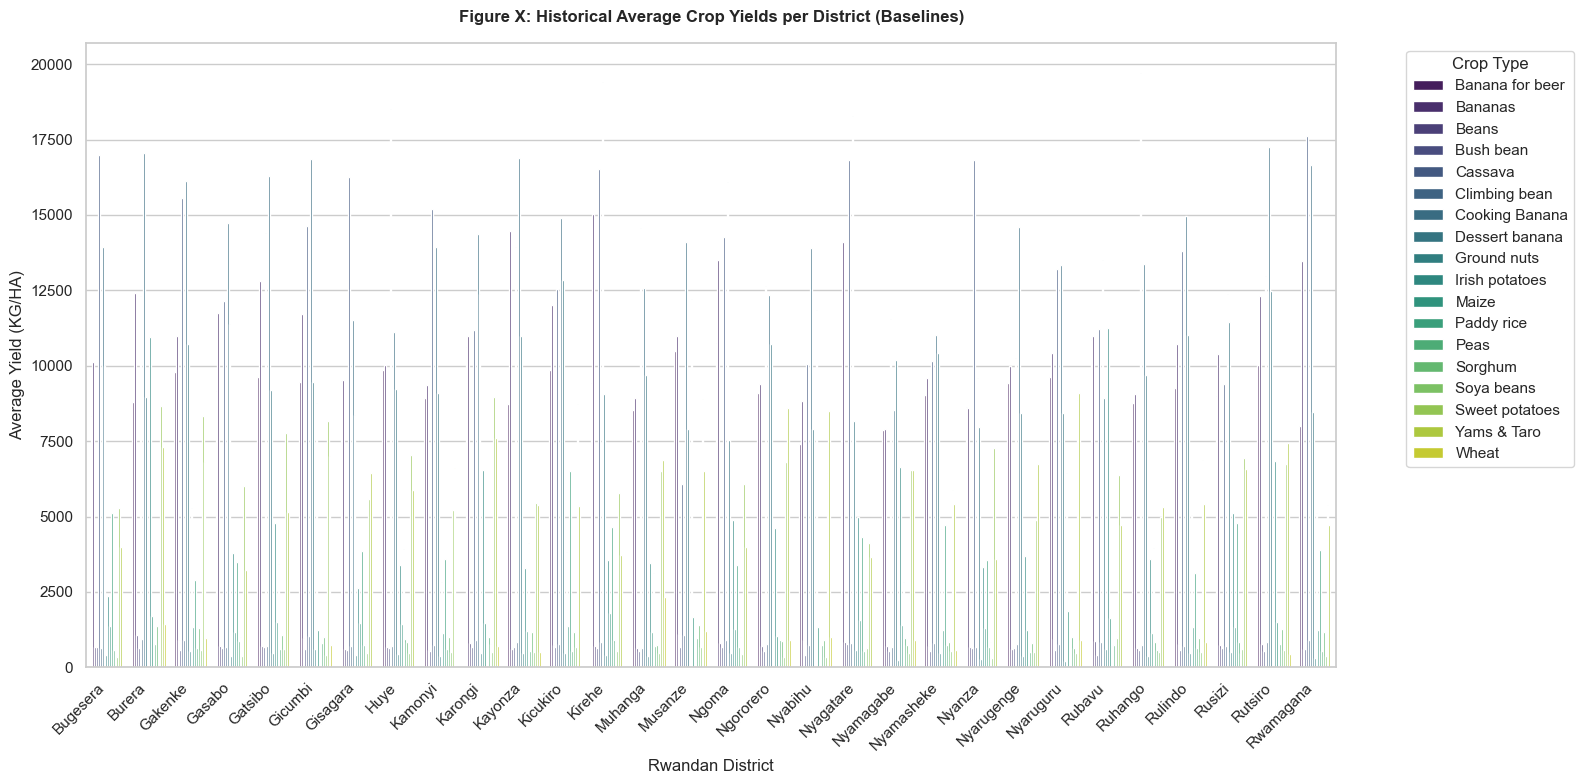

In [4]:
# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 8))

# Create a grouped bar chart
chart = sns.barplot(
    data=baseline_df, 
    x='District', 
    y='Baseline_Yield_KG_HA', 
    hue='Crop',
    palette='viridis'
)

# Formatting the chart for your academic report
plt.title('Figure X: Historical Average Crop Yields per District (Baselines)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Rwandan District', fontsize=12)
plt.ylabel('Average Yield (KG/HA)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save the graph so you can paste it into your Word Document
plt.savefig('baseline_yield_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# 1. Initialize an empty dictionary
baseline_dict = {}

# 2. Loop through the dataframe to create the "District_Crop" keys
for index, row in baseline_df.iterrows():
    key = f"{row['District']}_{row['Crop']}"
    # Round to 2 decimal places for clean data
    baseline_dict[key] = round(row['Baseline_Yield_KG_HA'], 2)

# 3. Print the perfectly formatted Python dictionary
print("--- COPY AND PASTE THIS INTO YOUR FASTAPI BACKEND ---")
print("REGIONAL_BASELINES = " + json.dumps(baseline_dict, indent=4))

--- COPY AND PASTE THIS INTO YOUR FASTAPI BACKEND ---
REGIONAL_BASELINES = {
    "Bugesera_Banana for beer": 8345.13,
    "Bugesera_Bananas": 10135.38,
    "Bugesera_Beans": 668.37,
    "Bugesera_Bush bean": 678.77,
    "Bugesera_Cassava": 16980.52,
    "Bugesera_Climbing bean": 640.56,
    "Bugesera_Cooking Banana": 13941.3,
    "Bugesera_Dessert banana": 9987.26,
    "Bugesera_Ground nuts": 424.89,
    "Bugesera_Irish potatoes": 2376.12,
    "Bugesera_Maize": 1371.34,
    "Bugesera_Paddy rice": 5107.64,
    "Bugesera_Peas": 576.37,
    "Bugesera_Sorghum": 746.23,
    "Bugesera_Soya beans": 330.2,
    "Bugesera_Sweet potatoes": 5286.6,
    "Bugesera_Yams & Taro": 3999.4,
    "Burera_Banana for beer": 8794.61,
    "Burera_Bananas": 12416.18,
    "Burera_Beans": 1077.82,
    "Burera_Bush bean": 652.29,
    "Burera_Cassava": 12304.61,
    "Burera_Climbing bean": 929.86,
    "Burera_Cooking Banana": 17071.36,
    "Burera_Dessert banana": 8959.47,
    "Burera_Irish potatoes": 10945.81,
   

In [6]:
# Calculate the national average for each crop regardless of district
global_fallbacks = df.groupby('Crop')['Yield_KG_HA'].mean().reset_index()

fallback_dict = {}
for index, row in global_fallbacks.iterrows():
    fallback_dict[row['Crop']] = round(row['Yield_KG_HA'], 2)

print("--- COPY AND PASTE THIS INTO YOUR FASTAPI BACKEND ---")
print("GLOBAL_CROP_FALLBACKS = " + json.dumps(fallback_dict, indent=4))

--- COPY AND PASTE THIS INTO YOUR FASTAPI BACKEND ---
GLOBAL_CROP_FALLBACKS = {
    "Banana for beer": 9282.29,
    "Bananas": 11014.1,
    "Beans": 759.39,
    "Bush bean": 609.51,
    "Cassava": 13912.28,
    "Climbing bean": 792.57,
    "Cooking Banana": 14326.18,
    "Dessert banana": 9702.79,
    "Ground nuts": 433.28,
    "Irish potatoes": 5536.92,
    "Maize": 1384.15,
    "Paddy rice": 3966.2,
    "Peas": 752.68,
    "Sorghum": 970.29,
    "Soya beans": 511.88,
    "Sweet potatoes": 6686.23,
    "Wheat": 944.46,
    "Yams & Taro": 5939.82
}


In [7]:
import json

# 1. Initialize the master dictionary structure
final_json_output = {
    "regional_baselines": {},
    "global_fallbacks": {}
}

# 2. Populate Regional Baselines (using baseline_df from Cell 2)
for index, row in baseline_df.iterrows():
    key = f"{row['District']}_{row['Crop']}"
    final_json_output["regional_baselines"][key] = round(row['Baseline_Yield_KG_HA'], 2)

# 3. Calculate and Populate Global Fallbacks
global_fallbacks = df.groupby('Crop')['Yield_KG_HA'].mean().reset_index()
for index, row in global_fallbacks.iterrows():
    final_json_output["global_fallbacks"][row['Crop']] = round(row['Yield_KG_HA'], 2)

# 4. Export to a JSON file
with open('crop_baselines.json', 'w') as json_file:
    json.dump(final_json_output, json_file, indent=4)

print("Success! 'crop_baselines.json' has been generated in your current directory.")

Success! 'crop_baselines.json' has been generated in your current directory.
